# Assignment 06 — EC: e-commerce order flow with RNNs

**Dataset:** Online Retail II (UCI), a UK online retailer, 2009-12 → 2011-12. **Service-process view:** every invoice is an *order*, every invoice starting with `C` is a *cancellation / return*.
**Task:** for each of the 750 most-ordered products, read the last **28 open days** (10 features) and predict the **units ordered on the next open day** (many-to-one regression, one model for all products).
**Runs:** `EC-SC-RNN` (NumPy), `EC-TF-RNN` (Keras), `EC-PT-RNN` (PyTorch) with identical architecture and starting weights, plus LSTM/GRU in Keras and PyTorch.
Concepts and formulas are in [00_rnn_concepts.ipynb](00_rnn_concepts.ipynb).

## 1. Setup

One seed (42) for Python, NumPy, Keras and PyTorch; one set of hyper-parameters for every implementation (hidden size 32, Adam lr 1e-3, batch 128, at most 30 epochs, early stopping with patience 5 on validation loss, gradient clipping at global norm 1.0). Run IDs follow `<dataset>-<implementation>-<model>`: `SC` = NumPy scratch, `TF` = Keras, `PT` = PyTorch. Setting `A6_SMOKE=1` shrinks everything for a quick test and writes to `smoke/` folders.

In [1]:
import os, time, json, random, warnings
from pathlib import Path
os.environ.setdefault("TF_CPP_MIN_LOG_LEVEL", "2")
os.environ.setdefault("TF_ENABLE_ONEDNN_OPTS", "0")
import numpy as np, pandas as pd, matplotlib.pyplot as plt, seaborn as sns
import tensorflow as tf
from tensorflow import keras
from tensorflow.keras import layers
import torch, torch.nn as nn, torch.nn.functional as Fn
warnings.filterwarnings("ignore")
sns.set_theme(style="whitegrid", context="notebook")
plt.rcParams.update({"figure.dpi": 100, "savefig.dpi": 150, "savefig.bbox": "tight"})

SEED = 42
SMOKE = os.environ.get("A6_SMOKE") == "1"          # quick test: few series, 2 epochs, outputs go to */smoke/
random.seed(SEED); np.random.seed(SEED); keras.utils.set_random_seed(SEED); torch.manual_seed(SEED)

CODE = "EC"
DATA = Path("../dataset/ec")
RES = Path("results") / ("smoke" if SMOKE else "")
IMG = Path("../report/images") / ("smoke" if SMOKE else "")
RES.mkdir(parents=True, exist_ok=True); IMG.mkdir(parents=True, exist_ok=True)

# one fixed set of hyper-parameters for every implementation (PLAN 3.4)
H = 32            # hidden size: dimension of the state h_t
BATCH = 128       # windows per parameter update (shuffled within the train period every epoch)
LR = 1e-3         # Adam learning rate (constant)
EPS = 1e-7        # Adam epsilon
CLIP = 1.0        # gradient clipping: global norm of all gradients
PATIENCE = 5      # early stopping: epochs without improvement of the validation loss before stopping
MAX_EPOCHS = 2 if SMOKE else 30
T = 28                                              # window length

dev = torch.device("cuda" if torch.cuda.is_available() else "mps" if torch.backends.mps.is_available() else "cpu")
print("TensorFlow", tf.__version__, "| Keras", keras.__version__, "| PyTorch", torch.__version__)
print("TF GPUs:", tf.config.list_physical_devices("GPU"), "| PT device:", dev, "| smoke:", SMOKE)

TensorFlow 2.21.0 | Keras 3.15.1 | PyTorch 2.14.0+cpu


TF GPUs: [] | PT device: cpu | smoke: False


### Hyperparameters and configuration

| Name | Value | Meaning |
|---|---|---|
| Series pooled into one model | 750 products | each series contributes its own windows |
| Time steps per series | 604 open days | |
| Window length T | 28 | steps read before each prediction |
| Features per step F | 10 | listed in the data section below |
| Windows (train / validation / test) | 295,500 / 68,250 / 68,250 | chronological 70 / 15 / 15 split by target day |
| Recurrent layers | 1 | one cell applied over the T steps |
| Hidden size H | 32 | dimension of h_t |
| Activation | tanh | inside the cell; the output unit is linear |
| Dropout, weight decay | none | early stopping is the only regularisation |
| Loss | MSE | on the z-scored target |
| Optimizer | Adam | beta1 = 0.9, beta2 = 0.999, epsilon = 1e-7 |
| Learning rate | 1e-3 | constant |
| Batch size | 128 | windows per update, shuffled within train every epoch |
| Maximum epochs | 30 | 2 in smoke mode |
| Early stopping | patience 5 | on the validation loss; best weights restored |
| Gradient clipping | 1.0 | global norm of all gradients |
| Initial W_xh | Glorot uniform | U(-sqrt(6/(F+H)), +sqrt(6/(F+H))) |
| Initial W_hh | orthogonal | Q factor of a QR decomposition of a Gaussian matrix |
| Initial W_hy | Glorot uniform | U(-sqrt(6/(H+1)), +sqrt(6/(H+1))) |
| Initial biases | 0 | b and b_y |
| Random seed | 42 | Python, NumPy, Keras, PyTorch |
| Numeric precision | float32 | the gradient check runs in float64 |

## 2. Data

Steps, in order: drop 34k exact duplicate lines → real orders (not `C…`, quantity > 0, price > 0) define the **open days** (the shop never sells on Saturday and closes over Christmas, so those days are *dropped*, not filled with 0) → keep the 750 products with the most distinct invoices → per product and day aggregate the features → `log1p` the counts → z-score on the **train period only**.

| Feature | Meaning | Transform |
|---|---|---|
| `units` (**target**) | units ordered | `log1p`, z-score. E.g. 0 → 0, 9 → 2.30, 99 → 4.61: ratios become differences, so a 10-fold jump looks like a constant step |
| `orders`, `customers` | distinct invoices / distinct customer IDs (22 % of lines have no ID) | `log1p`, z |
| `cancel_units` | units in cancellation invoices (returns) | `log1p`, z |
| `price` | mean unit price | `log`, z |
| `gap` | calendar days since the previous open day (1 normally, 2–3 over Sunday/holidays) | z |
| `dow`, `doy` sin/cos | weekday and day of year on a circle, so Sunday and Monday are neighbours | none |

**Split.** Chronological by *target day*: first 70 % of open days train, next 15 % validation, last 15 % test. A window ending just before a boundary may look back into the earlier split, but its target is always inside its own split, so nothing from the future is used. Windows are built once; the same arrays go to all three implementations.

**Metrics.** RMSE and MAE in units sold (after undoing z-score and `log1p`), RMSE in the z-scored log space (what the models minimise), and out-of-sample R² against the train-mean predictor, $1-\sum(y-\hat y)^2/\sum y^2$ in z-space. Baselines: *persistence* ($\hat y_t=y_{t-1}$), *seasonal naive* ($y_{t-6}$, one open-day week) and the train mean.

In [2]:
N_SERIES = 60 if SMOKE else 750
raw = pd.read_csv(DATA / "online_retail_II.csv", encoding="latin1").drop_duplicates()
raw["StockCode"] = raw["StockCode"].astype(str)
raw["day"] = pd.to_datetime(raw["InvoiceDate"]).dt.normalize()
raw["cancel"] = raw["Invoice"].astype(str).str.startswith("C")
sales = raw[~raw.cancel & (raw.Quantity > 0) & (raw.Price > 0)]          # real orders
canc = raw[raw.cancel]                                                    # cancellations / returns
days = np.sort(sales["day"].unique()); D = len(days)                      # days on which the shop sold something
top = sales.groupby("StockCode")["Invoice"].nunique().nlargest(N_SERIES).index
print(f"{len(raw):,} lines after de-duplication | {D} open days {str(days[0])[:10]} -> {str(days[-1])[:10]} | {len(top)} products | {len(canc):,} cancellation lines")

agg = sales[sales.StockCode.isin(top)].groupby(["StockCode", "day"]).agg(
    units=("Quantity", "sum"), orders=("Invoice", "nunique"), customers=("Customer ID", "nunique"), price=("Price", "mean"))
cn = canc[canc.StockCode.isin(top)].assign(q=lambda d: -d.Quantity).groupby(["StockCode", "day"])["q"].sum().rename("cancel")
full = agg.join(cn, how="outer").reindex(pd.MultiIndex.from_product([top, days], names=["StockCode", "day"]))
for c in ("units", "orders", "customers", "cancel"): full[c] = full[c].fillna(0).clip(lower=0)
full["price"] = full.groupby(level=0)["price"].transform(lambda s: s.ffill().bfill())
nS = len(top); mat = lambda c: full[c].to_numpy().reshape(nS, D)
U, O, Cu, Cn, P = (mat(c) for c in ("units", "orders", "customers", "cancel", "price"))

gap = np.r_[1, np.diff(days).astype("timedelta64[D]").astype(int)].astype(float)    # calendar days since previous open day
di = pd.DatetimeIndex(days)
cal = np.stack([np.sin(2 * np.pi * di.dayofweek / 7), np.cos(2 * np.pi * di.dayofweek / 7),
                np.sin(2 * np.pi * di.dayofyear / 365.25), np.cos(2 * np.pi * di.dayofyear / 365.25)], 1)
FEATS = ["units", "orders", "customers", "cancel_units", "price", "gap", "dow_sin", "dow_cos", "doy_sin", "doy_cos"]
S = np.zeros((nS, D, len(FEATS)), np.float32)
S[..., 0], S[..., 1], S[..., 2], S[..., 3] = np.log1p(U), np.log1p(O), np.log1p(Cu), np.log1p(Cn)
S[..., 4] = np.log(P); S[..., 5] = gap[None]; S[..., 6:] = cal[None]

# chronological split on the TARGET day: 70 % / 15 % / 15 % of the open days
c1, c2 = int(0.70 * D), int(0.85 * D)
mu = S[:, :c1, :6].reshape(-1, 6).mean(0); sd = S[:, :c1, :6].reshape(-1, 6).std(0)     # train period only
S[..., :6] = (S[..., :6] - mu) / sd
mu_t, sd_t = float(mu[0]), float(sd[0])                                   # target = z-scored log1p(units)

def make_windows(lo, hi):
    """All windows whose target day t+1 lies in [lo, hi); the look-back part may reach into an earlier split."""
    ends = np.arange(max(lo - 1, T - 1), hi - 1)
    X = np.concatenate([S[:, t - T + 1:t + 1] for t in ends]); y = np.concatenate([S[:, t + 1, 0] for t in ends])
    return X, y, np.repeat(ends + 1, nS), np.tile(np.arange(nS), len(ends))
Xtr, ytr, tr_day, tr_ser = make_windows(0, c1)
Xva, yva, va_day, va_ser = make_windows(c1, c2)
Xte, yte, te_day, te_ser = make_windows(c2, D)
if not SMOKE: np.savez(DATA / "splits.npz", days=days.astype("datetime64[D]"), series=np.array(top), c1=c1, c2=c2, T=T, mu=mu, sd=sd)
print(f"windows: train {len(Xtr):,} | validation {len(Xva):,} | test {len(Xte):,} | total {len(Xtr)+len(Xva)+len(Xte):,}")
print(f"X shape (N, T, F) = {Xtr.shape} | split days: train < {str(days[c1])[:10]} <= validation < {str(days[c2])[:10]} <= test")

to_units = lambda z: np.expm1(np.asarray(z) * sd_t + mu_t).clip(min=0)
KEY_METRIC = "rmse_units"
def metrics_fn(z_true, z_pred):
    """RMSE / MAE in units sold; R2 against the train-mean predictor (z = 0), on the log scale."""
    ut, up = to_units(z_true), to_units(z_pred)
    return dict(rmse_units=float(np.sqrt(np.mean((ut - up) ** 2))), mae_units=float(np.mean(np.abs(ut - up))),
                rmse=float(np.sqrt(np.mean((z_true - z_pred) ** 2))), r2_oos=float(1 - np.sum((z_true - z_pred) ** 2) / np.sum(z_true ** 2)))

BASELINES = {"persistence (y[t]=y[t-1])": Xte[:, -1, 0], "seasonal naive (y[t]=y[t-6])": Xte[:, -6, 0], "train mean": np.zeros(len(yte), np.float32)}
SHOW = 0                                                                  # series shown in forecast plots: the most-ordered product
def overlay_slice(pred, n=48):
    ix = np.where(te_ser == SHOW)[0][-n:]
    return days[te_day[ix]], to_units(yte[ix]), to_units(pred[ix]), f"units sold, product {top[SHOW]}"

1,033,036 lines after de-duplication | 604 open days 2009-12-01 -> 2011-12-09 | 750 products | 19,104 cancellation lines


windows: train 295,500 | validation 68,250 | test 68,250 | total 432,000
X shape (N, T, F) = (295500, 28, 10) | split days: train < 2011-05-10 <= validation < 2011-08-25 <= test


### Shared evaluation helpers

Every run, whatever the implementation, goes through `finalize`: it predicts validation and test windows, computes the metrics above, stores a JSON record in `results/`, saves the loss and forecast figures and prints a one-line summary. Time per epoch is the median of epochs 2+ (epoch 1 includes one-time set-up).

In [3]:
RUNS = {}   # run_id -> result record (+ test predictions)

def median_epoch_time(times):
    times = list(times)
    return float(np.median(times[1:] if len(times) > 1 else times))   # epoch 1 includes one-time set-up

def infer_ms_per_1k(predict_fn, X, reps=3):
    n = min(len(X), 10000); ts = []
    for _ in range(reps):
        t0 = time.perf_counter(); predict_fn(X[:n]); ts.append(time.perf_counter() - t0)
    return float(np.median(ts)) / n * 1e6

def plot_loss(run_id, hist):
    best = int(np.argmin(hist["val_loss"]))
    fig, ax = plt.subplots(figsize=(5.5, 3.4))
    ax.plot(range(1, len(hist["loss"]) + 1), hist["loss"], label="train")
    ax.plot(range(1, len(hist["val_loss"]) + 1), hist["val_loss"], label="validation")
    ax.axvline(best + 1, ls=":", c="grey"); ax.set(xlabel="epoch", ylabel="MSE (z-scored target)", title=f"{run_id}: loss"); ax.legend()
    fig.savefig(IMG / f"{run_id}_loss.png"); plt.show()

def plot_forecast(run_id, pred):
    xs, actual, predicted, ylabel = overlay_slice(pred)
    fig, (a, b) = plt.subplots(1, 2, figsize=(11, 3.4), gridspec_kw={"width_ratios": [2.2, 1]})
    a.plot(xs, actual, label="actual", lw=1.5); a.plot(xs, predicted, label=run_id, lw=1.2)
    a.set(ylabel=ylabel, title=f"{run_id}: forecast on the test period (one series)"); a.legend(); a.tick_params(axis="x", rotation=30)
    res = yte - pred
    b.hist(res, bins=80, color="C2"); b.set(xlabel="residual (z-scored target)", title="residuals, all test windows")
    fig.savefig(IMG / f"{run_id}_forecast.png"); plt.show()

def finalize(run_id, impl, kind, hist, params, times, total, predict_fn):
    pv, pt = predict_fn(Xva), predict_fn(Xte)
    rec = dict(run_id=run_id, impl=impl, model=kind, params=int(params), epochs_run=len(hist["loss"]),
               best_epoch=int(np.argmin(hist["val_loss"]) + 1), time_per_epoch_s=median_epoch_time(times),
               total_time_s=float(total), infer_ms_per_1k=infer_ms_per_1k(predict_fn, Xte),
               val=metrics_fn(yva, pv), test=metrics_fn(yte, pt),
               history={k: [float(v) for v in vs] for k, vs in hist.items()})
    (RES / f"{run_id}.json").write_text(json.dumps(rec, indent=1))
    RUNS[run_id] = dict(rec, pred=pt)
    plot_loss(run_id, hist); plot_forecast(run_id, pt)
    print(f"{run_id}: params {rec['params']:,} | epochs {rec['epochs_run']} (best {rec['best_epoch']}) | "
          f"{rec['time_per_epoch_s']:.1f}s/epoch | total {rec['total_time_s']:.0f}s | test " +
          ", ".join(f"{k} {v:.4f}" for k, v in rec["test"].items()))
    return rec

## 3. Exploratory data analysis

Three things to read from the plots: (1) the series has a strong yearly peak before Christmas, and the split puts the second Christmas peak into train/validation and the final weeks into test; (2) weekdays are similar but the shop is closed on Saturday, which is why `gap` and a 6-day seasonal baseline make sense; (3) most product-days have no sale at all, so the target is intermittent and a naive "last value" forecast will be hard to beat. Cancellations are a service-quality signal and are kept as a feature.

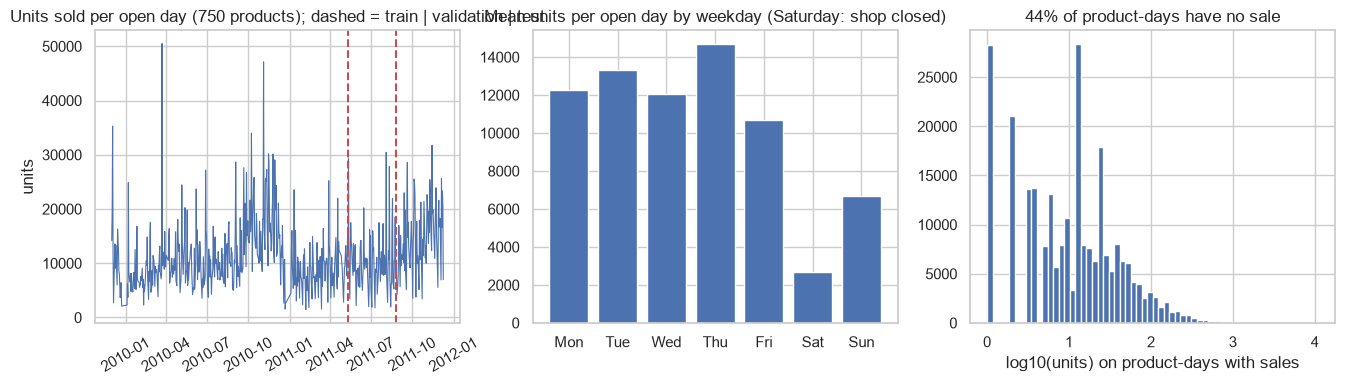

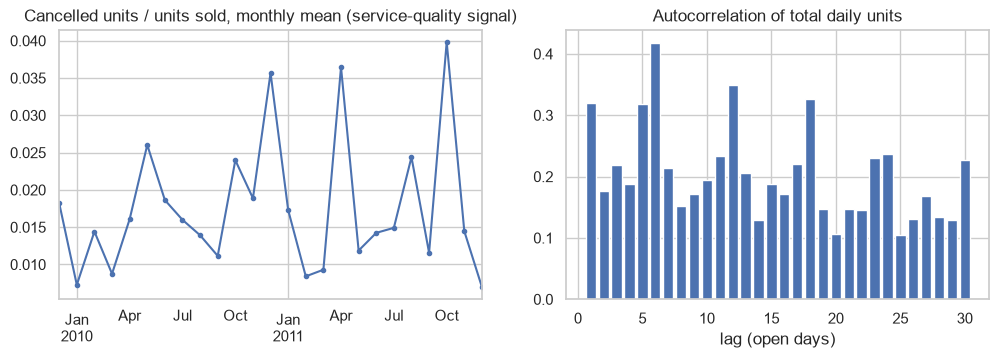

weekday means (open days): {0: 12242.0, 1: 13331.0, 2: 12033.0, 3: 14676.0, 4: 10695.0, 5: 2703.0, 6: 6662.0}
cancelled units are 2.1% of units sold | largest autocorrelation at lag 6: 0.42 (lag 1: 0.32)


In [4]:
orders_total = O.sum(0); units_total = U.sum(0); canc_total = Cn.sum(0)
fig, ax = plt.subplots(1, 3, figsize=(16, 3.8))
ax[0].plot(days, units_total, lw=0.8); ax[0].axvline(days[c1], c="C3", ls="--"); ax[0].axvline(days[c2], c="C3", ls="--")
ax[0].set(title="Units sold per open day (750 products); dashed = train | validation | test", ylabel="units"); ax[0].tick_params(axis="x", rotation=30)
dow = pd.Series(units_total, index=di).groupby(di.dayofweek).mean()
ax[1].bar(["Mon", "Tue", "Wed", "Thu", "Fri", "Sat", "Sun"], [dow.get(i, 0) for i in range(7)]); ax[1].set(title="Mean units per open day by weekday (Saturday: shop closed)")
ax[2].hist(np.log10(U[U > 0]), bins=60); ax[2].set(xlabel="log10(units) on product-days with sales", title=f"{(U == 0).mean():.0%} of product-days have no sale")
fig.savefig(IMG / f"{CODE}_eda_series.png"); plt.show()

m = pd.Series(canc_total / np.maximum(units_total, 1), index=di).groupby(di.to_period("M")).mean()
fig, ax = plt.subplots(1, 2, figsize=(12, 3.5))
m.plot(ax=ax[0], marker="o", ms=3); ax[0].set(title="Cancelled units / units sold, monthly mean (service-quality signal)", xlabel="")
r = [np.corrcoef(units_total[:-k], units_total[k:])[0, 1] for k in range(1, 31)]
ax[1].bar(range(1, 31), r); ax[1].set(xlabel="lag (open days)", title="Autocorrelation of total daily units")
fig.savefig(IMG / f"{CODE}_eda_service.png"); plt.show()
print(f"weekday means (open days): {dow.round(0).to_dict()}")
print(f"cancelled units are {Cn.sum()/U.sum():.1%} of units sold | largest autocorrelation at lag {int(np.argmax(r[1:]))+2}: {max(r[1:]):.2f} (lag 1: {r[0]:.2f})")

## 4. RNN from scratch (NumPy)  —  run `EC-SC-RNN`

**Recurrence.** $h_t=\tanh(x_tW_{xh}+h_{t-1}W_{hh}+b)$, $h_0=0$, and the prediction uses only the last state: $\hat y=h_TW_{hy}+b_y$. The same $W_{xh},W_{hh},b$ are reused at every time step (weight sharing), so the parameter count does not depend on $T$.

**Back-propagation through time.** With $z_t=x_tW_{xh}+h_{t-1}W_{hh}+b$ and loss $L=\frac1N\sum(\hat y-y)^2$:

$$\frac{\partial L}{\partial h_T}=\frac{2}{N}(\hat y-y)W_{hy}^\top,\qquad \frac{\partial L}{\partial z_t}=\frac{\partial L}{\partial h_t}\odot(1-h_t^2),\qquad \frac{\partial L}{\partial h_{t-1}}=\frac{\partial L}{\partial z_t}W_{hh}^\top$$

and the shared weights collect a contribution from every step: $\partial L/\partial W_{hh}=\sum_t h_{t-1}^\top\,\partial L/\partial z_t$ (likewise $W_{xh}$ with $x_t$, and $b$). The code loops over time only (vectorised over the batch). Gradients are clipped to a global norm of 1 and fed to a hand-written Adam.

**Shapes for this dataset.** Input $(N,28,10)$ → $x_t\in\mathbb R^{10}$, $h_t\in\mathbb R^{32}$ → $\hat y\in\mathbb R$. Parameters: $W_{xh}$ $10\times32=320$, $W_{hh}$ $32\times32=1024$, $b$ 32, head $32+1$ → **1,409**.

In [5]:
class ScratchRNN:
    """Single-layer vanilla RNN, many-to-one: h_t = tanh(x_t Wxh + h_{t-1} Whh + b), yhat = h_T Why + by. NumPy only."""
    def __init__(self, F, H, seed=SEED, dtype=np.float32):
        rng = np.random.default_rng(seed)
        lim = np.sqrt(6 / (F + H))                                   # Glorot uniform (as Keras kernel)
        q, r = np.linalg.qr(rng.standard_normal((H, H)))             # orthogonal recurrent matrix (as Keras)
        lh = np.sqrt(6 / (H + 1))
        self.p = {"Wxh": rng.uniform(-lim, lim, (F, H)), "Whh": q * np.sign(np.diag(r)), "bh": np.zeros(H),
                  "Why": rng.uniform(-lh, lh, (H, 1)), "by": np.zeros(1)}
        self.p = {k: v.astype(dtype) for k, v in self.p.items()}

    def n_params(self): return int(sum(v.size for v in self.p.values()))

    def forward(self, X):
        p = self.p; N, Tn, _ = X.shape
        xw = X @ p["Wxh"]                                            # all x_t Wxh at once: (N, T, H)
        h = np.zeros((N, p["Whh"].shape[0]), X.dtype); hs = [h]
        for t in range(Tn):                                          # the only loop is over time
            h = np.tanh(xw[:, t] + h @ p["Whh"] + p["bh"]); hs.append(h)
        return (h @ p["Why"] + p["by"])[:, 0], hs

    def loss_grads(self, X, y):
        """MSE loss and its gradients by back-propagation through time. Also returns ||dL/dh_t||, t = 1..T."""
        p = self.p; yhat, hs = self.forward(X); N, Tn, _ = X.shape
        err = yhat - y; loss = float(np.mean(err ** 2))
        dy = (2.0 / N) * err[:, None]                                # dL/dyhat
        g = {k: np.zeros_like(v) for k, v in p.items()}
        g["Why"] = hs[-1].T @ dy; g["by"] = dy.sum(0)
        dh = dy @ p["Why"].T                                         # dL/dh_T
        norms = np.zeros(Tn)
        for t in range(Tn, 0, -1):
            norms[t - 1] = np.linalg.norm(dh)
            dz = dh * (1.0 - hs[t] ** 2)                             # through tanh: dL/dz_t
            g["Wxh"] += X[:, t - 1].T @ dz
            g["Whh"] += hs[t - 1].T @ dz
            g["bh"] += dz.sum(0)
            dh = dz @ p["Whh"].T                                     # dL/dh_{t-1}
        return loss, g, norms

    def predict(self, X, bs=4096):
        return np.concatenate([self.forward(X[i:i + bs])[0] for i in range(0, len(X), bs)])


class Adam:
    def __init__(self, params, lr=LR, b1=0.9, b2=0.999, eps=EPS):
        self.lr, self.b1, self.b2, self.eps, self.t = lr, b1, b2, eps, 0
        self.m = {k: np.zeros_like(v) for k, v in params.items()}; self.v = {k: np.zeros_like(v) for k, v in params.items()}
    def step(self, params, grads):
        self.t += 1
        for k in params:
            self.m[k] = self.b1 * self.m[k] + (1 - self.b1) * grads[k]
            self.v[k] = self.b2 * self.v[k] + (1 - self.b2) * grads[k] ** 2
            mh = self.m[k] / (1 - self.b1 ** self.t); vh = self.v[k] / (1 - self.b2 ** self.t)
            params[k] -= self.lr * mh / (np.sqrt(vh) + self.eps)


def clip_global_norm(grads, max_norm=CLIP):
    total = np.sqrt(sum(float((g.astype(np.float64) ** 2).sum()) for g in grads.values()))
    scale = min(1.0, max_norm / (total + 1e-6))
    for k in grads: grads[k] *= scale
    return total


def fit_scratch(model, Xtr, ytr, Xva, yva):
    opt = Adam(model.p); rng = np.random.default_rng(SEED)
    hist = {"loss": [], "val_loss": []}; times = []; best, wait, best_p = np.inf, 0, None
    t_all = time.perf_counter()
    for ep in range(MAX_EPOCHS):
        t0 = time.perf_counter(); perm = rng.permutation(len(Xtr)); tot = 0.0
        for i in range(0, len(perm), BATCH):
            idx = perm[i:i + BATCH]
            loss, g, _ = model.loss_grads(Xtr[idx], ytr[idx])
            clip_global_norm(g); opt.step(model.p, g); tot += loss * len(idx)
        val = float(np.mean((model.predict(Xva) - yva) ** 2))
        hist["loss"].append(tot / len(perm)); hist["val_loss"].append(val); times.append(time.perf_counter() - t0)
        if val < best - 1e-12: best, wait, best_p = val, 0, {k: v.copy() for k, v in model.p.items()}
        else: wait += 1
        if wait >= PATIENCE: break
    model.p = best_p                                                 # restore best weights
    return hist, times, time.perf_counter() - t_all

### Gradient check

Before trusting hand-written back-propagation, compare it with a central finite difference $\frac{L(\theta+\epsilon)-L(\theta-\epsilon)}{2\epsilon}$ ($\epsilon=10^{-6}$, float64) for **every** parameter on 8 real windows. The error is measured per parameter as $\max|a-n|\,/\,\max|a|$ (analytic $a$, numerical $n$), because entries whose gradient is almost zero would otherwise be dominated by finite-difference round-off. Below $10^{-5}$ means the BPTT code is right.

In [6]:
def gradient_check(F, n=8, eps=1e-6, seed=0):
    """Compare analytic BPTT gradients with central finite differences, in float64, on n real windows."""
    m = ScratchRNN(F, H, seed=seed, dtype=np.float64)
    for k in ("bh", "by"): m.p[k] = np.random.default_rng(1).normal(0, 0.1, m.p[k].shape)      # non-zero biases test those gradients too
    X, y = Xtr[:n].astype(np.float64), ytr[:n].astype(np.float64)
    _, g, _ = m.loss_grads(X, y); rows = []
    for k, v in m.p.items():
        num = np.zeros_like(v)
        for ix in np.ndindex(*v.shape):
            old = v[ix]; v[ix] = old + eps; lp = m.loss_grads(X, y)[0]; v[ix] = old - eps; lm = m.loss_grads(X, y)[0]; v[ix] = old
            num[ix] = (lp - lm) / (2 * eps)
        rel = np.abs(g[k] - num).max() / max(np.abs(g[k]).max(), 1e-12)      # error relative to the parameter's largest gradient entry
        rows.append((k, v.shape, float(rel)))
    return pd.DataFrame(rows, columns=["parameter", "shape", "max error / max |gradient|"])

gc = gradient_check(Xtr.shape[2]); display(gc)
assert gc['max error / max |gradient|'].max() < 1e-5, 'BPTT gradients disagree with finite differences'

,parameter,shape,max error / max |gradient|
0,Wxh,"(10, 32)",3.794784e-10
1,Whh,"(32, 32)",9.294235e-10
2,bh,"(32,)",4.398734e-10
3,Why,"(32, 1)",2.117885e-10
4,by,"(1,)",5.028961e-12


### Trainable parameters of the core RNN

| Parameter | Shape | Count |
|---|---|---|
| Input weights W_xh | F x H | 10 x 32 = 320 |
| Recurrent weights W_hh | H x H | 32 x 32 = 1,024 |
| Cell bias b | H | 32 |
| Output weights W_hy | H x 1 | 32 |
| Output bias b_y | 1 | 1 |
| **Total** | F*H + H*H + H + H + 1 | **1,409** |

The same 1,409 parameters appear in the NumPy, Keras and PyTorch models (asserted in the PyTorch section). LSTM and GRU have one W / U / bias block per gate and candidate (4 and 3 blocks), which gives the larger counts printed in the PyTorch section; `nn.LSTM` keeps two bias vectors per block, so it has 4*32 = 128 more parameters than Keras's LSTM.

### Training

The scratch model starts from the weights `W0` (Glorot input matrix, orthogonal recurrent matrix, zero biases). The same `W0` is copied into the Keras and PyTorch models so that all three implementations begin from the identical function. Mini-batches are shuffled with a seeded generator; Keras and PyTorch shuffle with their own generators, so batch order is not bit-identical across frameworks.

scratch parameters: 1409  = F*H + H*H + H + H + 1 = 1409


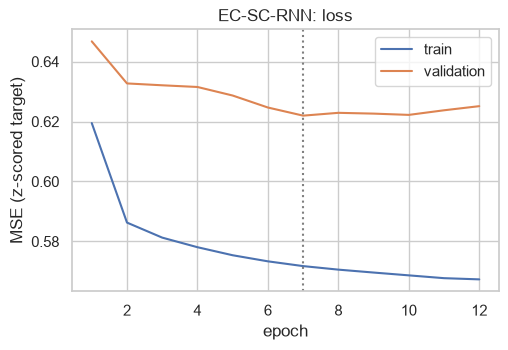

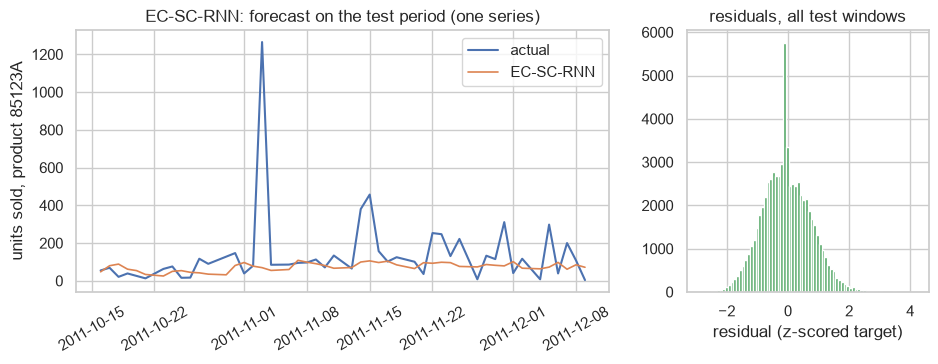

EC-SC-RNN: params 1,409 | epochs 12 (best 7) | 3.9s/epoch | total 47s | test rmse_units 62.5119, mae_units 15.9041, rmse 0.7924, r2_oos 0.4395


In [7]:
F_ = Xtr.shape[2]
W0 = {k: v.copy() for k, v in ScratchRNN(F_, H).p.items()}
sc = ScratchRNN(F_, H)
print('scratch parameters:', sc.n_params(), ' = F*H + H*H + H + H + 1 =', F_ * H + H * H + H + H + 1)
hist, times, total = fit_scratch(sc, Xtr, ytr, Xva, yva)
finalize(f'{CODE}-SC-RNN', 'Scratch', 'RNN', hist, sc.n_params(), times, total, sc.predict);

### Where does the gradient go?

$\partial L/\partial h_t$ is the learning signal that reaches step $t$. It is multiplied by $W_{hh}^\top\,\mathrm{diag}(1-h^2)$ at every step back in time, so it shrinks (or explodes) geometrically with the distance from the output. For the 28-day window the plot shows how much of the error signal the first day still receives, before and after training. Since the target is next-day units, the last few days carry most of the information; a vanishing signal is mostly harmless here but limits how much a vanilla RNN can use of the last month.

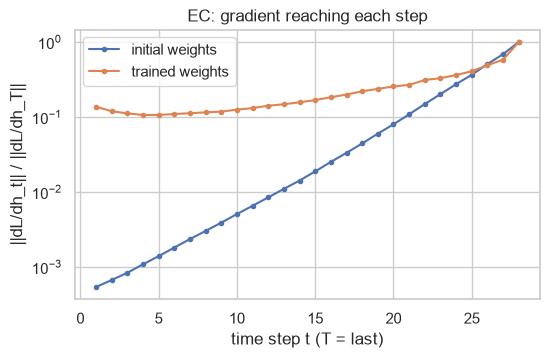

gradient at the first step is 0.137 of the gradient at the last step (trained), 0.001 (initial)


In [8]:
idx = np.random.default_rng(0).choice(len(Xte), 512, replace=False)
trained = sc.p; norms_trained = sc.loss_grads(Xte[idx], yte[idx])[2]
sc.p = ScratchRNN(F_, H).p; norms_init = sc.loss_grads(Xte[idx], yte[idx])[2]; sc.p = trained
fig, ax = plt.subplots(figsize=(6, 3.5))
for n_, l_ in ((norms_init, "initial weights"), (norms_trained, "trained weights")): ax.semilogy(range(1, T + 1), n_ / n_[-1], marker="o", ms=3, label=l_)
ax.set(xlabel="time step t (T = last)", ylabel="||dL/dh_t|| / ||dL/dh_T||", title=f"{CODE}: gradient reaching each step"); ax.legend()
fig.savefig(IMG / f"{CODE}-SC-RNN_gradnorm.png"); plt.show()
print(f"gradient at the first step is {norms_trained[0] / norms_trained[-1]:.3f} of the gradient at the last step (trained), {norms_init[0] / norms_init[-1]:.3f} (initial)")

## 5. RNN in Keras  —  runs `EC-TF-RNN`, `EC-TF-LSTM`, `EC-TF-GRU`

Keras hides the whole loop of §4 behind one layer: `SimpleRNN(32)` computes the same $h_t=\tanh(x_tW+h_{t-1}U+b)$ and returns the last state; `Dense(1)` is the head; `fit` runs shuffled mini-batches, Adam with `global_clipnorm=1.0` and `EarlyStopping(restore_best_weights=True)`. The scratch weights `W0` are copied in with `set_weights([kernel (10,32), recurrent_kernel (32,32), bias (32)])`. The summary below shows 1,409 parameters.

In [9]:
def build_keras(kind, F, Tn, copy_init=None):
    cell = {"RNN": layers.SimpleRNN, "LSTM": layers.LSTM, "GRU": layers.GRU}[kind]
    m = keras.Sequential([layers.Input((Tn, F)), cell(H), layers.Dense(1)])
    m.compile(optimizer=keras.optimizers.Adam(LR, epsilon=EPS, global_clipnorm=CLIP), loss="mse")
    if copy_init is not None:                                        # SimpleRNN weights: [kernel (F,H), recurrent (H,H), bias (H)]
        m.layers[0].set_weights([copy_init["Wxh"], copy_init["Whh"], copy_init["bh"]])
        m.layers[1].set_weights([copy_init["Why"], copy_init["by"]])
    return m

class EpochTimer(keras.callbacks.Callback):
    def on_train_begin(self, logs=None): self.times = []
    def on_epoch_begin(self, epoch, logs=None): self.t0 = time.perf_counter()
    def on_epoch_end(self, epoch, logs=None): self.times.append(time.perf_counter() - self.t0)

def run_keras(kind, copy_init=None):
    run_id = f"{CODE}-TF-{kind}"; keras.utils.set_random_seed(SEED)
    m = build_keras(kind, Xtr.shape[2], Xtr.shape[1], copy_init)
    timer = EpochTimer(); es = keras.callbacks.EarlyStopping(monitor="val_loss", patience=PATIENCE, restore_best_weights=True)
    t0 = time.perf_counter()
    h = m.fit(Xtr, ytr, validation_data=(Xva, yva), batch_size=BATCH, epochs=MAX_EPOCHS, shuffle=True, callbacks=[es, timer], verbose=0)
    total = time.perf_counter() - t0
    pred = lambda X: m.predict(X, batch_size=4096, verbose=0)[:, 0]
    return finalize(run_id, "Keras", kind, h.history, m.count_params(), timer.times, total, pred)

Model: "sequential"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ simple_rnn (SimpleRNN)          │ (None, 32)             │         1,376 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense (Dense)                   │ (None, 1)              │            33 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 1,409 (5.50 KB)

 Trainable params: 1,409 (5.50 KB)

 Non-trainable params: 0 (0.00 B)

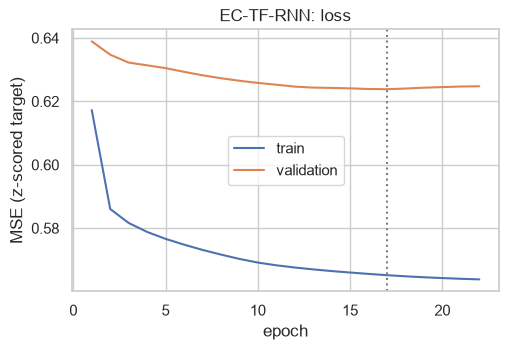

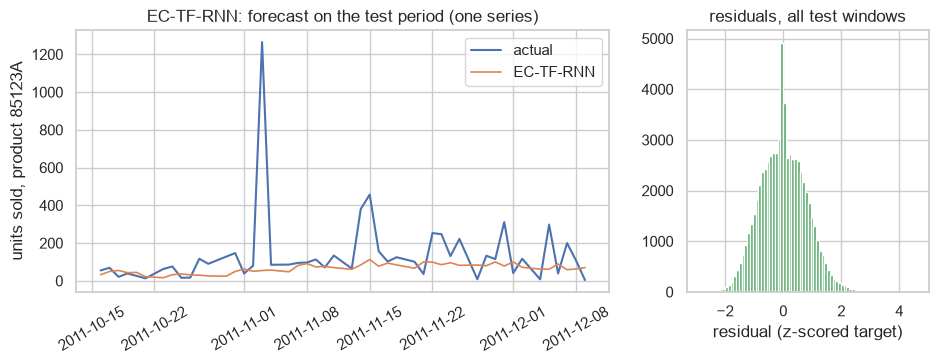

EC-TF-RNN: params 1,409 | epochs 22 (best 17) | 6.2s/epoch | total 143s | test rmse_units 63.0100, mae_units 16.0221, rmse 0.7938, r2_oos 0.4375


In [10]:
build_keras('RNN', Xtr.shape[2], T, W0).summary()
run_keras('RNN', copy_init=W0);

**Extras: LSTM and GRU.** Same data and settings, framework-default initialisation (Glorot input, orthogonal recurrent, zero bias; LSTM forget-gate bias 1 in Keras). They add gates (see `00_rnn_concepts.ipynb`), so they have 4× (LSTM) and 3× (GRU) the recurrent parameters.

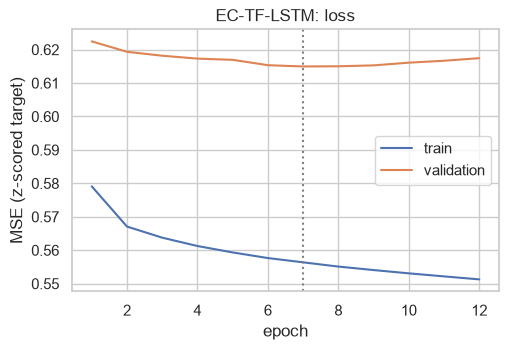

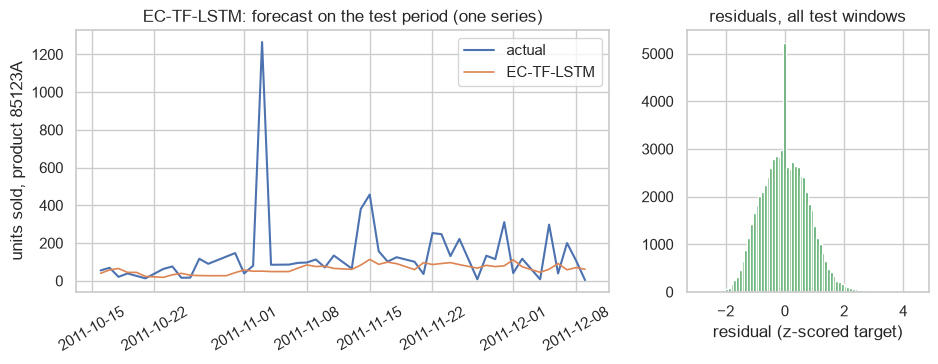

EC-TF-LSTM: params 5,537 | epochs 12 (best 7) | 14.6s/epoch | total 178s | test rmse_units 62.4426, mae_units 15.9271, rmse 0.7875, r2_oos 0.4463


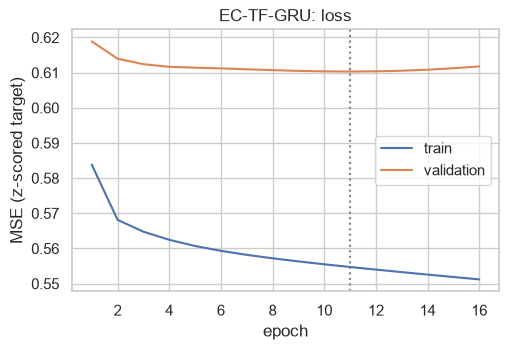

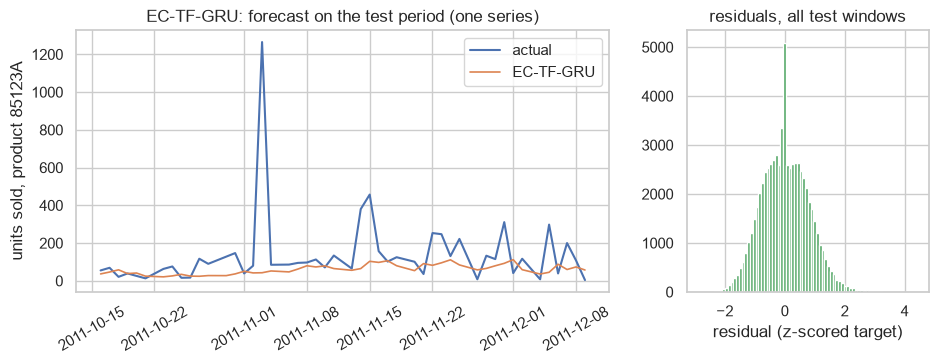

EC-TF-GRU: params 4,257 | epochs 16 (best 11) | 16.4s/epoch | total 267s | test rmse_units 62.4136, mae_units 15.8937, rmse 0.7857, r2_oos 0.4489


In [11]:
run_keras('LSTM'); run_keras('GRU');

## 6. RNN in PyTorch  —  runs `EC-PT-RNN`, `EC-PT-LSTM`, `EC-PT-GRU`

PyTorch sits in between: `nn.RNN(10, 32, batch_first=True)` is the recurrence (it expects `(N, T, F)`), the training loop is written by hand (`zero_grad → forward → loss.backward() → clip_grad_norm_ → step`). `nn.RNN` stores transposed matrices (`weight_ih` is $32\times10$) and **two** biases; the second one is zeroed and frozen so that the core run has exactly the same 1,409 parameters.

In [12]:
class TorchSeq(nn.Module):
    def __init__(self, kind, F, hidden=H):
        super().__init__()
        self.rnn = {"RNN": nn.RNN, "LSTM": nn.LSTM, "GRU": nn.GRU}[kind](F, hidden, batch_first=True)   # nn.RNN default nonlinearity = tanh
        self.head = nn.Linear(hidden, 1)
    def forward(self, x):
        out, _ = self.rnn(x)
        return self.head(out[:, -1]).squeeze(-1)                     # last time step only (many-to-one)

def build_torch(kind, F, copy_init=None):
    torch.manual_seed(SEED); m = TorchSeq(kind, F)
    if copy_init is not None:                                        # nn.RNN stores W_ih (H,F), W_hh (H,H): transpose of ours
        with torch.no_grad():
            m.rnn.weight_ih_l0.copy_(torch.from_numpy(copy_init["Wxh"].T)); m.rnn.weight_hh_l0.copy_(torch.from_numpy(copy_init["Whh"].T))
            m.rnn.bias_ih_l0.copy_(torch.from_numpy(copy_init["bh"])); m.rnn.bias_hh_l0.zero_()
            m.head.weight.copy_(torch.from_numpy(copy_init["Why"].T)); m.head.bias.copy_(torch.from_numpy(copy_init["by"]))
        m.rnn.bias_hh_l0.requires_grad_(False)                       # second bias frozen at 0 -> same parameter count as Keras / scratch
    return m.to(dev)

def n_trainable(m): return sum(p.numel() for p in m.parameters() if p.requires_grad)

def predict_torch(m, X, bs=4096):
    m.eval(); out = []
    with torch.no_grad():
        for i in range(0, len(X), bs): out.append(m(torch.from_numpy(X[i:i + bs]).to(dev)).cpu().numpy())
    return np.concatenate(out)

def fit_torch(m):
    params = [p for p in m.parameters() if p.requires_grad]
    opt = torch.optim.Adam(params, lr=LR, eps=EPS)
    Xt, yt = torch.from_numpy(Xtr).to(dev), torch.from_numpy(ytr).to(dev)
    Xv, yv = torch.from_numpy(Xva).to(dev), torch.from_numpy(yva).to(dev)
    gen = torch.Generator().manual_seed(SEED)
    hist = {"loss": [], "val_loss": []}; times = []; best, wait, best_state = np.inf, 0, None
    t_all = time.perf_counter()
    for ep in range(MAX_EPOCHS):
        t0 = time.perf_counter(); m.train(); perm = torch.randperm(len(Xt), generator=gen).to(dev); tot = torch.zeros((), device=dev)
        for i in range(0, len(perm), BATCH):
            idx = perm[i:i + BATCH]
            opt.zero_grad(set_to_none=True)
            loss = Fn.mse_loss(m(Xt[idx]), yt[idx]); loss.backward()
            torch.nn.utils.clip_grad_norm_(params, CLIP); opt.step()
            tot += loss.detach() * len(idx)
        m.eval()
        with torch.no_grad():
            val = sum(((m(Xv[i:i + 4096]) - yv[i:i + 4096]) ** 2).sum().item() for i in range(0, len(Xv), 4096)) / len(Xv)
        hist["loss"].append(tot.item() / len(perm)); hist["val_loss"].append(val); times.append(time.perf_counter() - t0)
        if val < best - 1e-12: best, wait, best_state = val, 0, {k: v.detach().clone() for k, v in m.state_dict().items()}
        else: wait += 1
        if wait >= PATIENCE: break
    m.load_state_dict(best_state)                                    # restore best weights
    return hist, times, time.perf_counter() - t_all

def run_torch(kind, copy_init=None):
    run_id = f"{CODE}-PT-{kind}"
    m = build_torch(kind, Xtr.shape[2], copy_init)
    hist, times, total = fit_torch(m)
    return finalize(run_id, "PyTorch", kind, hist, n_trainable(m), times, total, lambda X: predict_torch(m, X))

### Same weights, same output

Before training the PyTorch core model, check the claim *different names, same function*: with identical weights, the scratch, Keras and PyTorch forward passes must agree to float32 precision, and the parameter counts must match exactly.

In [13]:
xs = Xva[:64]
y_sc = ScratchRNN(F_, H).forward(xs)[0]
y_k = build_keras("RNN", F_, T, W0).predict(xs, verbose=0)[:, 0]
pm = build_torch("RNN", F_, W0); y_p = predict_torch(pm, xs)
print(f"max |scratch - Keras|   = {np.abs(y_sc - y_k).max():.2e}\nmax |scratch - PyTorch| = {np.abs(y_sc - y_p).max():.2e}\nmax |Keras - PyTorch|   = {np.abs(y_k - y_p).max():.2e}")
assert max(np.abs(y_sc - y_k).max(), np.abs(y_sc - y_p).max()) < 1e-4
n_k = build_keras("RNN", F_, T, W0).count_params(); n_p = n_trainable(pm); n_s = ScratchRNN(F_, H).n_params()
print("parameters  scratch / Keras / PyTorch:", n_s, n_k, n_p); assert n_s == n_k == n_p
pc = pd.DataFrame({k: {"Keras": build_keras(k, F_, T).count_params(), "PyTorch (all params)": sum(p.numel() for p in build_torch(k, F_).parameters())} for k in ("RNN", "GRU", "LSTM")}).T
display(pc)

max |scratch - Keras|   = 4.77e-07
max |scratch - PyTorch| = 4.77e-07
max |Keras - PyTorch|   = 5.96e-07
parameters  scratch / Keras / PyTorch: 1409 1409 1409


,Keras,PyTorch (all params)
RNN,1409,1441
GRU,4257,4257
LSTM,5537,5665


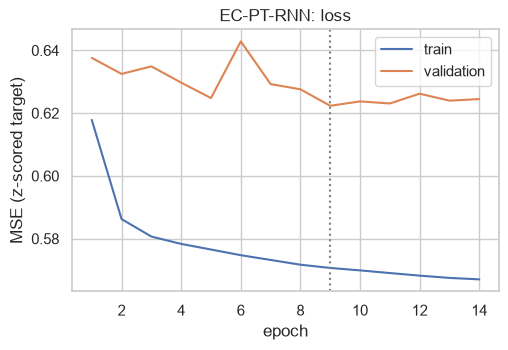

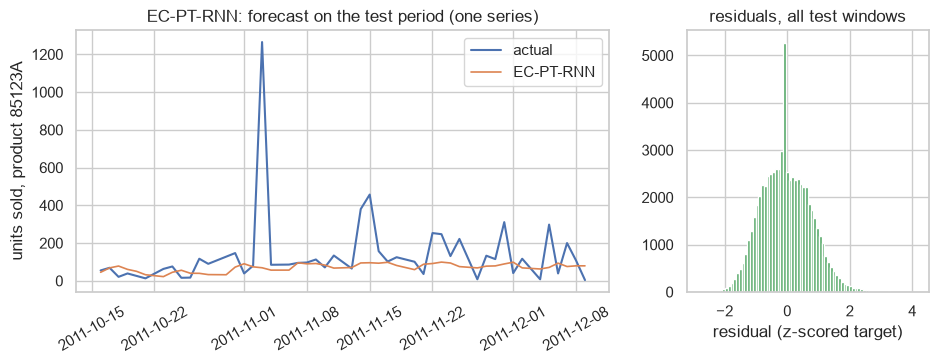

EC-PT-RNN: params 1,409 | epochs 14 (best 9) | 11.2s/epoch | total 156s | test rmse_units 62.8432, mae_units 16.0047, rmse 0.7929, r2_oos 0.4388


In [14]:
run_torch('RNN', copy_init=W0);

**Extras: LSTM and GRU** with PyTorch's default initialisation. `nn.LSTM` keeps two bias vectors per gate block (`b_ih`, `b_hh`), so it has 4·32 = 128 more parameters than Keras's LSTM; GRU matches because Keras uses `reset_after=True` (two biases) by default — see the table above.

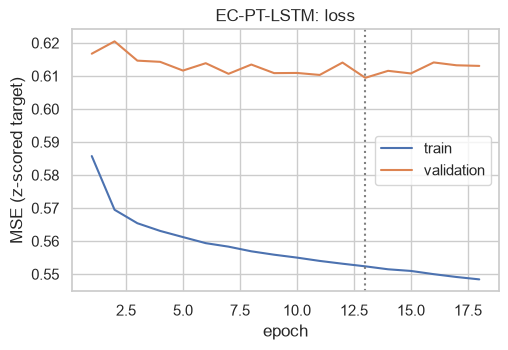

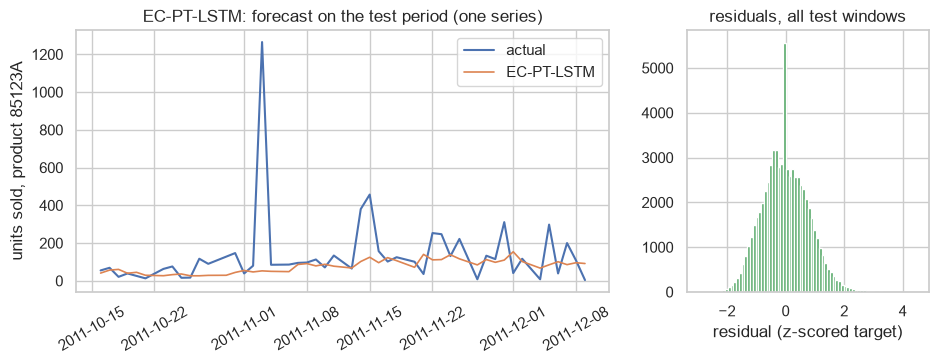

EC-PT-LSTM: params 5,665 | epochs 18 (best 13) | 22.0s/epoch | total 395s | test rmse_units 62.0310, mae_units 15.8328, rmse 0.7871, r2_oos 0.4469


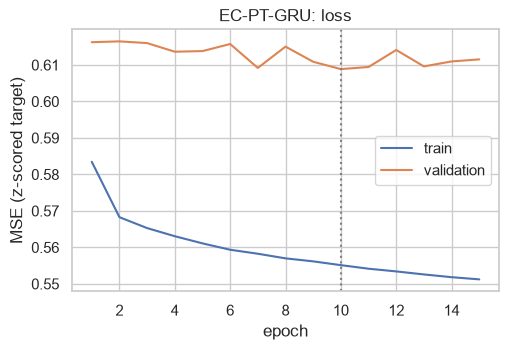

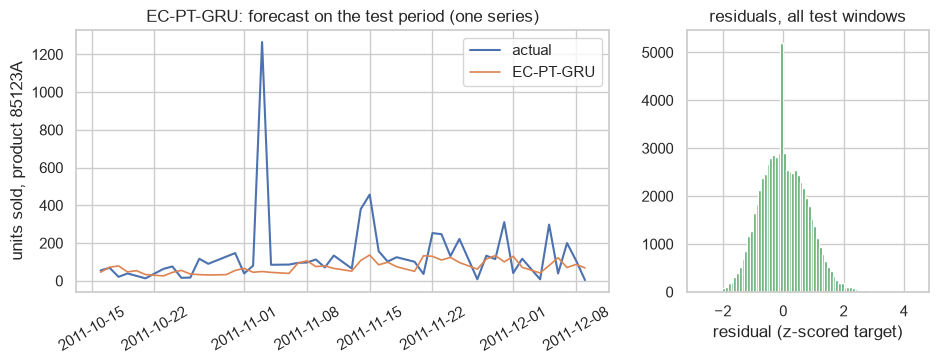

EC-PT-GRU: params 4,257 | epochs 15 (best 10) | 28.4s/epoch | total 428s | test rmse_units 62.2400, mae_units 15.8701, rmse 0.7862, r2_oos 0.4481


In [15]:
run_torch('LSTM'); run_torch('GRU');

## 7. Comparison

Everything below is on the **test** period (last 15 % of open days). Reading guide: (a) can any RNN beat *persistence* and *seasonal naive*? (b) do scratch, Keras and PyTorch agree when they start from the same weights? (c) do gates (LSTM/GRU) help on an intermittent demand series? (d) what does each implementation cost in time?

In [16]:
rows = []
for name, p in BASELINES.items():
    rows.append(dict(run_id=f"baseline: {name}", impl="-", **metrics_fn(yte, p)))
for rid, r in RUNS.items():
    rows.append(dict(run_id=rid, impl=r["impl"], params=r["params"], epochs=r["epochs_run"], best_epoch=r["best_epoch"],
                     s_per_epoch=round(r["time_per_epoch_s"], 2), total_s=round(r["total_time_s"]), infer_ms_per_1k=round(r["infer_ms_per_1k"], 2), **r["test"]))
table = pd.DataFrame(rows).set_index("run_id")
table.to_csv(RES / f"{CODE}_comparison.csv")
display(table.style.format(precision=4, na_rep="").background_gradient(subset=[c for c in table.columns if c in ("rmse", "rmse_units")], cmap="Greens_r"))

,impl,rmse_units,mae_units,rmse,r2_oos,params,epochs,best_epoch,s_per_epoch,total_s,infer_ms_per_1k
run_id,,,,,,,,,,,
baseline: persistence (y[t]=y[t-1]),-,82.6756,23.9104,1.0814,-0.0439,,,,,,
baseline: seasonal naive (y[t]=y[t-6]),-,81.0648,23.1944,1.0740,-0.0297,,,,,,
baseline: train mean,-,67.8801,19.2610,1.0584,0.0000,,,,,,
EC-SC-RNN,Scratch,62.5119,15.9041,0.7924,0.4395,1409.0000,12.0000,7.0000,3.9400,47.0000,5.5400
EC-TF-RNN,Keras,63.0100,16.0221,0.7938,0.4375,1409.0000,22.0000,17.0000,6.1600,143.0000,8.0200
EC-TF-LSTM,Keras,62.4426,15.9271,0.7875,0.4463,5537.0000,12.0000,7.0000,14.6300,178.0000,16.9000
EC-TF-GRU,Keras,62.4136,15.8937,0.7857,0.4489,4257.0000,16.0000,11.0000,16.3900,267.0000,15.0500
EC-PT-RNN,PyTorch,62.8432,16.0047,0.7929,0.4388,1409.0000,14.0000,9.0000,11.2100,156.0000,1.5400
EC-PT-LSTM,PyTorch,62.0310,15.8328,0.7871,0.4469,5665.0000,18.0000,13.0000,21.9700,395.0000,4.1400


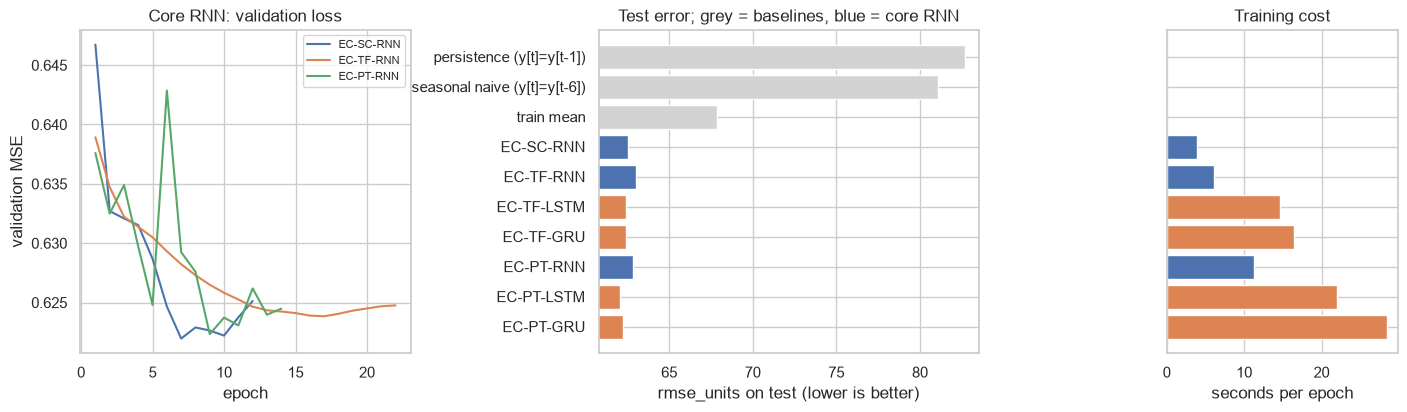

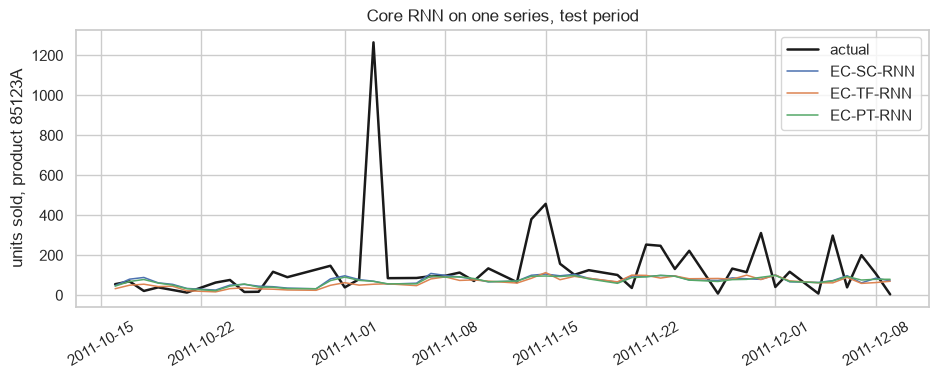

In [17]:
core = [f"{CODE}-SC-RNN", f"{CODE}-TF-RNN", f"{CODE}-PT-RNN"]
extra = [r for r in RUNS if r not in core]
fig = plt.figure(figsize=(17, 4.2)); gs = fig.add_gridspec(1, 3, wspace=0.6, width_ratios=[1, 1.15, 0.7])
a0 = fig.add_subplot(gs[0]); a1 = fig.add_subplot(gs[1]); a2 = fig.add_subplot(gs[2], sharey=a1)
for rid in core:
    h = RUNS[rid]["history"]; a0.plot(range(1, len(h["val_loss"]) + 1), h["val_loss"], label=rid)
a0.set(xlabel="epoch", ylabel="validation MSE", title="Core RNN: validation loss"); a0.legend(fontsize=8)
rm = KEY_METRIC
labels = list(BASELINES) + list(RUNS); vals = [metrics_fn(yte, p)[rm] for p in BASELINES.values()] + [RUNS[r]["test"][rm] for r in RUNS]
colors = ["lightgrey"] * len(BASELINES) + ["C0" if r in core else "C1" for r in RUNS]
a1.barh(labels, vals, color=colors); a1.invert_yaxis(); a1.set(xlabel=rm + " on test (lower is better)", title="Test error; grey = baselines, blue = core RNN")
a1.set_xlim(min(vals) * 0.98, max(vals) * 1.01)
a2.barh(labels, [0] * len(BASELINES) + [RUNS[r]["time_per_epoch_s"] for r in RUNS], color=colors)
a2.set(xlabel="seconds per epoch", title="Training cost"); plt.setp(a2.get_yticklabels(), visible=False)
fig.savefig(IMG / f"{CODE}_compare.png"); plt.show()

fig, ax = plt.subplots(figsize=(11, 3.6))
xs, actual, _, ylabel = overlay_slice(RUNS[core[0]]["pred"])
ax.plot(xs, actual, c="k", lw=1.8, label="actual")
for rid in core: ax.plot(xs, overlay_slice(RUNS[rid]["pred"])[2], lw=1.1, label=rid)
ax.set(ylabel=ylabel, title="Core RNN on one series, test period"); ax.legend(); ax.tick_params(axis="x", rotation=30)
fig.savefig(IMG / f"{CODE}_overlay.png"); plt.show()

## 8. Conclusion

1. **The recurrent models learn real structure here.** Test RMSE is 62.0–63.0 units for all seven RNNs against 67.9 for the train mean, 81.1 for seasonal naive and 82.7 for persistence (out-of-sample R² 0.44–0.45 on the log scale). The target is intermittent, so copying the last value is worse than predicting the mean; the RNN combines weekday/season encodings, order counts and cancellations.
2. **Scratch, Keras and PyTorch agree.** With identical starting weights the forward passes differ by < 6e-7 and the parameter counts match (1,409). After training the core RNN reaches RMSE 62.51 (scratch), 63.01 (Keras) and 62.84 (PyTorch), a spread of 0.8 %, which comes from different batch order and the epoch at which early stopping fires (7, 17 and 9), not from different mathematics.
3. **Gates help only a little.** LSTM and GRU reach 62.0–62.4 (best: PyTorch LSTM, 62.03), 0.5–1.5 % better than the vanilla RNN, at 2–3.5× the time per epoch and 3–4× the parameters. For a 28-day window on log-counts the vanilla RNN is already close to the best; training also raised the gradient reaching the first day from 0.1 % to 14 % of the last-step gradient, so the network uses more of the window after training.
4. **Cost.** Per epoch: scratch 3.9 s, Keras 6.2 s, PyTorch 11.2 s for the vanilla RNN on CPU. The NumPy loop wins on this small model (32 hidden units) because it carries no framework overhead; PyTorch is fastest at inference (1.5 ms per 1,000 windows vs 5.5 scratch, 8.0 Keras).
5. **Caveat.** One seed and one split; differences below ~1 % between runs should not be read as a ranking.